In [15]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [16]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

con = sqlite3.connect(r"C:\Users\BCA\Documents\Sem 3\OJT\Project 3.1\data\raw\ipl.db")

def q(sql):
    return pd.read_sql(sql, con)

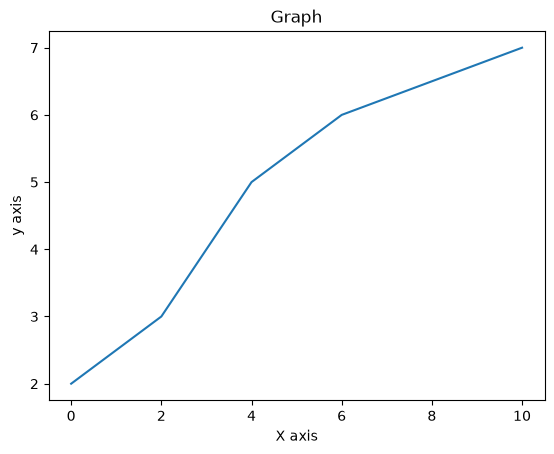

In [17]:
x = [0,2,4,6,10]
y = [2,3,5,6,7]

plt.plot(x,y)
plt.title('Graph')
plt.xlabel("X axis")
plt.ylabel("y axis")
plt.show()

<Axes: title={'center': 'Total balls in each phases'}, xlabel='Different phases of Innings', ylabel='Tital number of balls'>

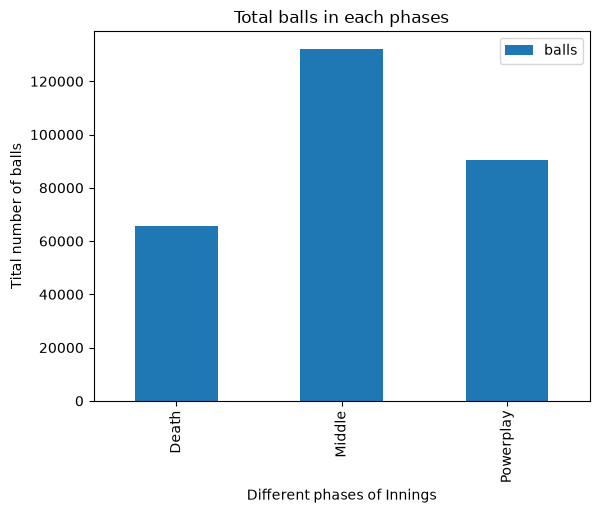

In [18]:
df = pd.read_sql("""select phase, count(*) as balls from v_ball group by phase;""", con)
df.plot(kind="bar",
        x="phase",
        y="balls",
        title="Total balls in each phases",
        xlabel="Different phases of Innings",
        ylabel="Tital number of balls")

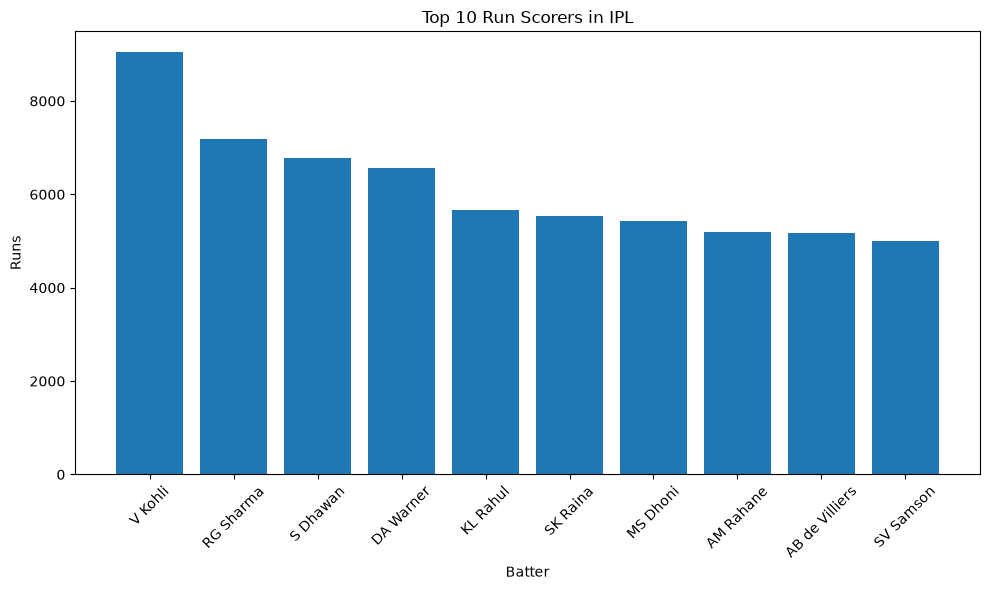

In [19]:
data = q("""
SELECT batter, SUM(batter_runs) AS runs
FROM v_ball
GROUP BY batter
ORDER BY runs DESC
LIMIT 10
""")

plt.figure(figsize=(10, 6))
plt.bar(data["batter"], data["runs"])
plt.title("Top 10 Run Scorers in IPL")
plt.xlabel("Batter")
plt.ylabel("Runs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

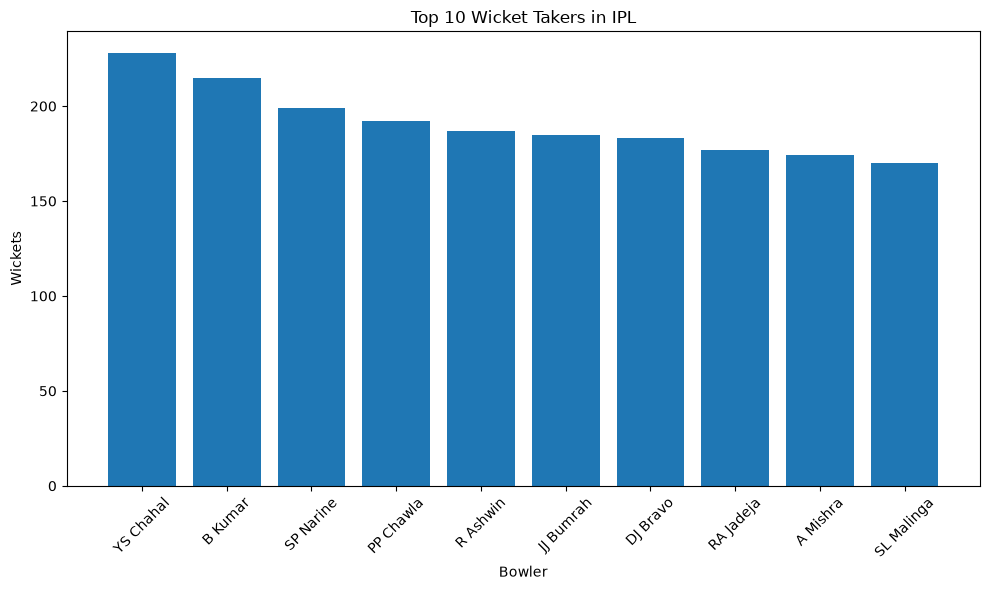

In [20]:
data = q("""
SELECT bowler, SUM(bowler_wicket) AS wickets
FROM v_ball
WHERE bowler_wicket = 1
GROUP BY bowler
ORDER BY wickets DESC
LIMIT 10
""")

plt.figure(figsize=(10, 6))
plt.bar(data["bowler"], data["wickets"])
plt.title("Top 10 Wicket Takers in IPL")
plt.xlabel("Bowler")
plt.ylabel("Wickets")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

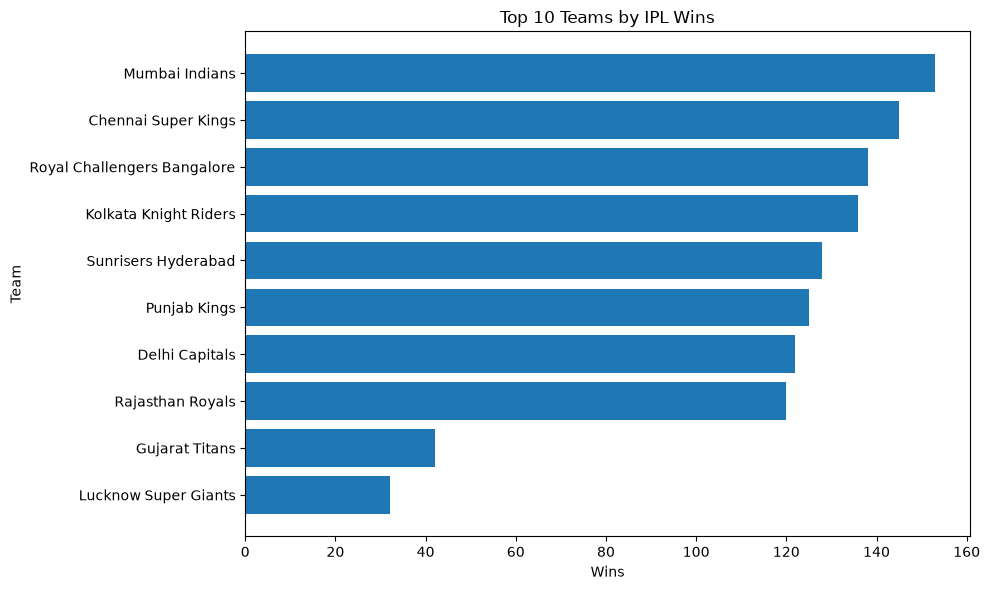

In [21]:
data = q("""
SELECT match_winner AS team,
       COUNT(*) AS wins
FROM matches
WHERE result = 'win'
GROUP BY match_winner
ORDER BY wins DESC
LIMIT 10
""")

plt.figure(figsize=(10, 6))
plt.barh(data["team"], data["wins"])
plt.title("Top 10 Teams by IPL Wins")
plt.xlabel("Wins")
plt.ylabel("Team")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

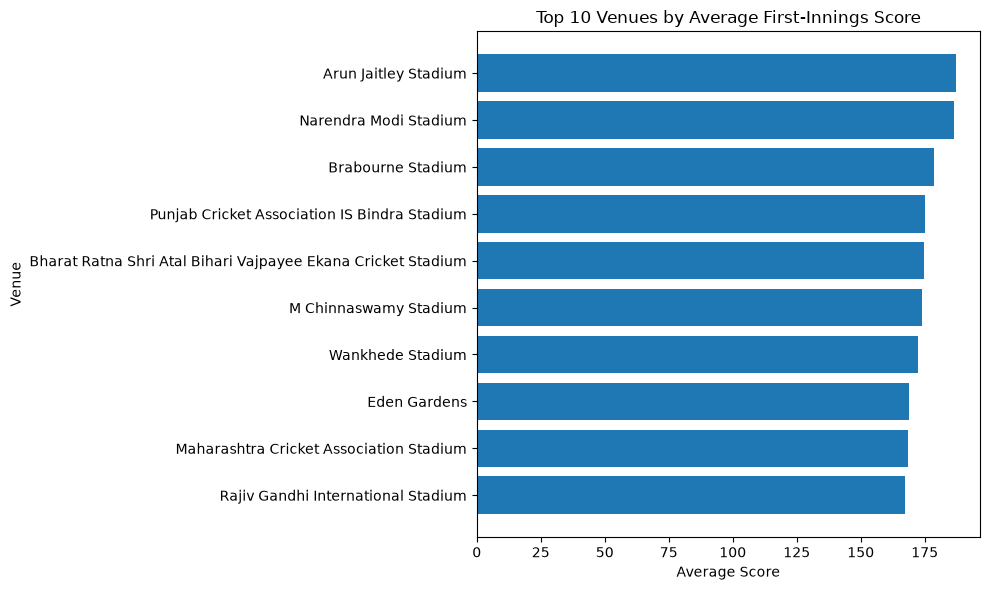

In [22]:
data = q("""
SELECT venue_clean AS venue,
       ROUND(AVG(first_innings_runs), 2) AS avg_score
FROM v_match_totals
WHERE first_innings_runs IS NOT NULL
GROUP BY venue_clean
HAVING COUNT(*) >= 20
ORDER BY avg_score DESC
LIMIT 10
""")

plt.figure(figsize=(10, 6))
plt.barh(data["venue"], data["avg_score"])
plt.title("Top 10 Venues by Average First-Innings Score")
plt.xlabel("Average Score")
plt.ylabel("Venue")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

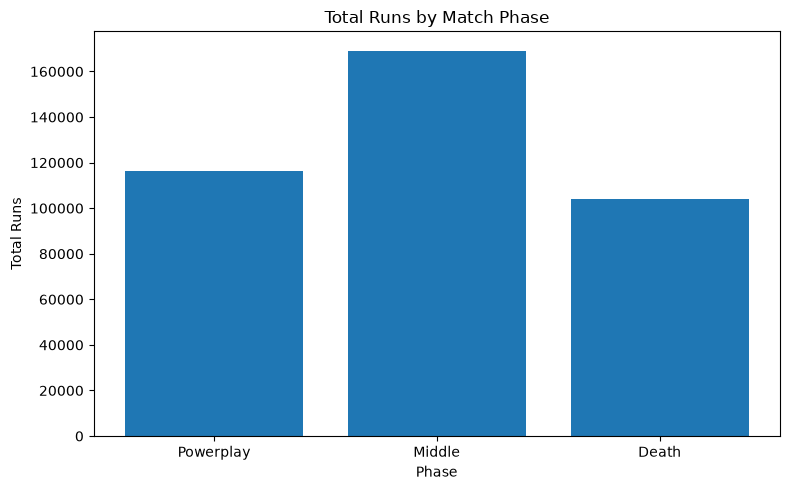

In [23]:
data = q("""
SELECT phase,
       SUM(total_runs) AS runs
FROM v_ball
GROUP BY phase
ORDER BY CASE phase
    WHEN 'Powerplay' THEN 1
    WHEN 'Middle' THEN 2
    WHEN 'Death' THEN 3
END
""")

plt.figure(figsize=(8, 5))
plt.bar(data["phase"], data["runs"])
plt.title("Total Runs by Match Phase")
plt.xlabel("Phase")
plt.ylabel("Total Runs")
plt.tight_layout()
plt.show()